In [25]:
# ======================================================================
# Importação das Bibliotecas Necessárias
# ======================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
import random
import seaborn as sns

In [2]:
# ======================================================================
# Definição das Sementes
# ======================================================================
SEMENTE = 1965
random.seed(SEMENTE)
np.random.seed(SEMENTE)


In [3]:
# ======================================================================
# Parâmetros do problema
# ======================================================================
H = 24  # número de horas
# cargas: (duração necessária em horas, potência kW)
CARGAS = {
    1: (2, 1.5),   # A precisa 2h, 1.5 kW
    2: (2, 2.0),   # B precisa 2h, 2.0 kW
    3: (2, 1.0),   # C precisa 2h, 1.0 kW
}
ACTIONS = [0, 1, 2, 3]  # 0=ligar nenhuma; 1=A; 2=B; 3=C

# penalidade se não terminar alguma carga no fim do dia
PENAL_INCOMPLETO = 50.0

In [4]:
# ======================================================================
# Parâmetros do Q Learning
# ======================================================================
ALPHA = 0.2
GAMMA = 0.98
EPS_START = 1.0
EPS_END   = 0.05
EPS_DECAY = 0.997  # por passo
EPISODES = 2000


In [5]:
def preco_base_24h():
    # barata: 0-6h; média: 6-17h; cara: 17-22h; média: 22-24h
    p = np.array([0.35]*6 + [0.55]*11 + [0.90]*5 + [0.55]*2, dtype=float)
    return p



In [6]:
def gera_preco_diario(ruido=0.05):
    base = preco_base_24h()
    ruido_vec = np.random.normal(0, ruido, size=base.shape)
    preco = np.clip(base + ruido_vec, 0.1, None)
    return preco

In [7]:
def state_to_index(t, rA, rB, rC):
    # t ∈ [0,H-1], r* ∈ [0,dur*]
    return (((t * (durA+1) + rA) * (durB+1) + rB) * (durC+1) + rC)



In [8]:
def step(state, action, preco):
    t, rA, rB, rC = state
    reward = 0.0

    # custo energético do passo
    if action == 0:
        # nenhuma carga ligada
        pass
    else:
        dur, pot = CARGAS[action]
        # só consome custo se ainda há horas a cumprir para essa carga
        if (action == 1 and rA > 0) or (action == 2 and rB > 0) or (action == 3 and rC > 0):
            reward -= preco[t] * pot  # custo = preço * potência nesse slot
            # "executa" 1h dessa carga
            if action == 1 and rA > 0: rA -= 1
            if action == 2 and rB > 0: rB -= 1
            if action == 3 and rC > 0: rC -= 1
        else:
            # ação inválida (ligar carga já concluída) -> custo zero, mas desperdiçou o slot
            pass

    # avança tempo
    t_next = t + 1
    done = (t_next == H)

    if done:
        # penalidade por resíduos não concluídos
        restante = rA + rB + rC
        if restante > 0:
            reward -= PENAL_INCOMPLETO * restante

    next_state = (min(t_next, H-1), rA, rB, rC)
    return next_state, reward, done

In [9]:
def index_to_state(idx):
    rC = idx % (durC+1); idx //= (durC+1)
    rB = idx % (durB+1); idx //= (durB+1)
    rA = idx % (durA+1); idx //= (durA+1)
    t  = idx
    return t, rA, rB, rC

In [10]:
def reset():
    # estado inicial: t=0 e cada carga com sua duração restante
    return (0, durA, durB, durC)

In [11]:
def Mostra_Custo_Episodio (custo_por_ep):
    plt.figure(figsize=(12,5))
    plt.plot(custo_por_ep, alpha=0.6, label="Custo por episódio")
    plt.plot(pd.Series(custo_por_ep).rolling(50).mean(), lw=2, label="Média móvel (50)")
    plt.title("Treinamento: custo por episódio (quanto menor, melhor)")
    plt.xlabel("Episódio")
    plt.ylabel("Custo")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [21]:
# -----------------------------
# Espaço de estados (t, rA, rB, rC)
# Codificação/decodificação de estado para índice da Q-table
# -----------------------------
durA, _ = CARGAS[1]
durB, _ = CARGAS[2]
durC, _ = CARGAS[3]

N_STATES = H * (durA+1) * (durB+1) * (durC+1)
N_ACTIONS = len(ACTIONS)

Q = np.zeros((N_STATES, N_ACTIONS), dtype=np.float32)
custo_por_ep = []
epsilon = EPS_START

for ep in range(EPISODES):
    preco = gera_preco_diario(ruido=0.05)
    state  = reset( )
    total_reward = 0.0

    done = False
    while not done:
        s_idx = state_to_index(*state)

        # ε-greedy
        if random.random() < epsilon:
            a_idx = random.randrange(N_ACTIONS)
        else:
            # desempate com ruído pequeno
            a_idx = int(np.argmax(Q[s_idx] + np.random.rand(N_ACTIONS)/1e6))

        action = ACTIONS[a_idx]
        next_state, reward, done = step(state, action, preco)

        ns_idx = state_to_index(*next_state)

        # atualização Q
        td_target = reward + (0.0 if done else GAMMA * np.max(Q[ns_idx]))
        Q[s_idx, a_idx] += ALPHA * (td_target - Q[s_idx, a_idx])

        state = next_state
        total_reward += reward

        # decaimento de ε
        if epsilon > EPS_END:
            epsilon *= EPS_DECAY

    # reward negativo = custo. Guardar custo positivo para interpretar melhor.
    custo_por_ep.append(-total_reward)

    if (ep+1) % 200 == 0:
        print(f"Episódio {ep+1}/{EPISODES} | Custo (médio nas últimas 200): {np.mean(custo_por_ep[-200:]):.3f} | ε={epsilon:.3f}")


Episódio 200/2000 | Custo (médio nas últimas 200): 68.860 | ε=0.050
Episódio 400/2000 | Custo (médio nas últimas 200): 94.532 | ε=0.050
Episódio 600/2000 | Custo (médio nas últimas 200): 43.529 | ε=0.050
Episódio 800/2000 | Custo (médio nas últimas 200): 27.988 | ε=0.050
Episódio 1000/2000 | Custo (médio nas últimas 200): 19.954 | ε=0.050
Episódio 1200/2000 | Custo (médio nas últimas 200): 13.199 | ε=0.050
Episódio 1400/2000 | Custo (médio nas últimas 200): 13.759 | ε=0.050
Episódio 1600/2000 | Custo (médio nas últimas 200): 11.732 | ε=0.050
Episódio 1800/2000 | Custo (médio nas últimas 200): 10.667 | ε=0.050
Episódio 2000/2000 | Custo (médio nas últimas 200): 11.393 | ε=0.050


In [13]:
# ======================================================================
# Avaliação (política gulosa) num novo dia de preços
# ======================================================================
preco_test = gera_preco_diario(ruido=0.05)
state = reset()
done = False
agenda = []  # guarda (hora, ação)
custo_total = 0.0

while not done:
    s_idx = state_to_index(*state)
    a_idx = int(np.argmax(Q[s_idx]))
    action = ACTIONS[a_idx]

    next_state, reward, done = step(state, action, preco_test)
    agenda.append((state[0], action))
    custo_total += -reward   # reward é negativo do custo (exceto penal)
    state = next_state


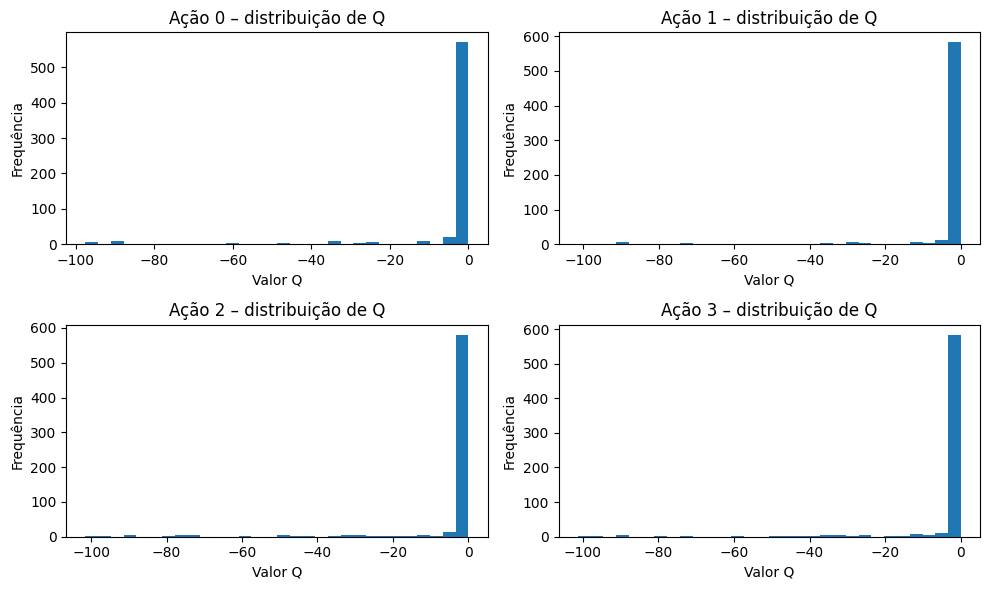

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# EXEMPLO: se já tiver Q pronto, comente estas duas linhas
# Q = np.random.rand(2000, 4)   # 2000 estados x 4 ações (exemplo)
# n_actions = Q.shape[1]
# ---------------------------------------------------------
n_actions = Q.shape[1]


# =============== 2) HEATMAP AGREGADO (BINNING) ===============
def binning_rows(mat, bin_size=100, agg='mean'):
    """
    Agrega linhas em blocos de 'bin_size'.
    Retorna uma matriz com (num_bins x n_actions).
    """
    n, m = mat.shape
    num_bins = int(np.ceil(n / bin_size))
    out = np.zeros((num_bins, m), dtype=float)
    for i in range(num_bins):
        start = i * bin_size
        end = min((i + 1) * bin_size, n)
        block = mat[start:end]
        if agg == 'mean':
            out[i] = block.mean(axis=0)
        elif agg == 'max':
            out[i] = block.max(axis=0)
        else:
            out[i] = block.mean(axis=0)
    return out

# =============== 3) HISTOGRAMAS POR AÇÃO ===============
# Distribuição dos valores Q de cada ação
rows = int(np.ceil(n_actions / 2))
cols = 2 if n_actions > 1 else 1
plt.figure(figsize=(10, 3*rows))
for a in range(n_actions):
    plt.subplot(rows, cols, a+1)
    plt.hist(Q[:, a], bins=30)
    plt.title(f'Ação {a} – distribuição de Q')
    plt.xlabel('Valor Q')
    plt.ylabel('Frequência')
plt.tight_layout()
plt.show()



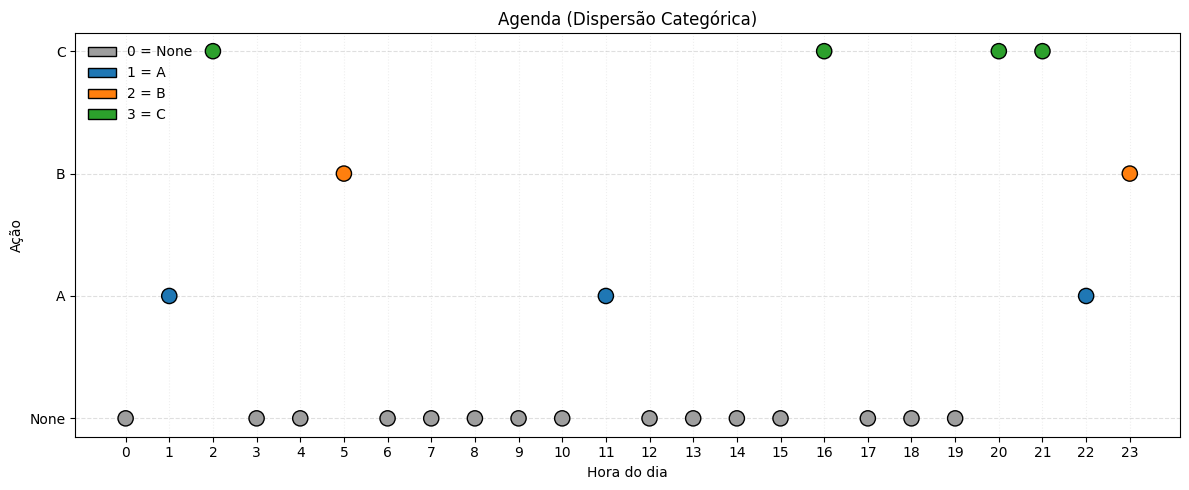

In [ ]:
schedule = agenda
# Vetores para plot
hours = np.array([h for h, a in schedule])
acts  = np.array([a for h, a in schedule])

# Mapas para rótulos e cores
label_map = {0: "None", 1: "A", 2: "B", 3: "C"}
color_map = {0: "#9e9e9e", 1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c"}  # cinza, azul, laranja, verde
colors = [color_map[a] for a in acts]
legend_elems = [Patch(facecolor=color_map[k], edgecolor='k', label=f"{k} = {label_map[k]}") for k in label_map]


fig = plt.figure(figsize=(12, 5))   # cria a figura com tamanho definido
ax = fig.add_subplot(111)             # adiciona os eixos

ax.scatter(hours, acts, c=colors, s=120, edgecolors='k', zorder=3)
ax.set_xticks(hours)
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels([label_map[i] for i in [0, 1, 2, 3]])
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Ação")
ax.set_title("Agenda (Dispersão Categórica)")
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', linestyle=':', alpha=0.2)
ax.legend(handles=legend_elems, loc="upper left", frameon=False)

plt.tight_layout()
plt.show()



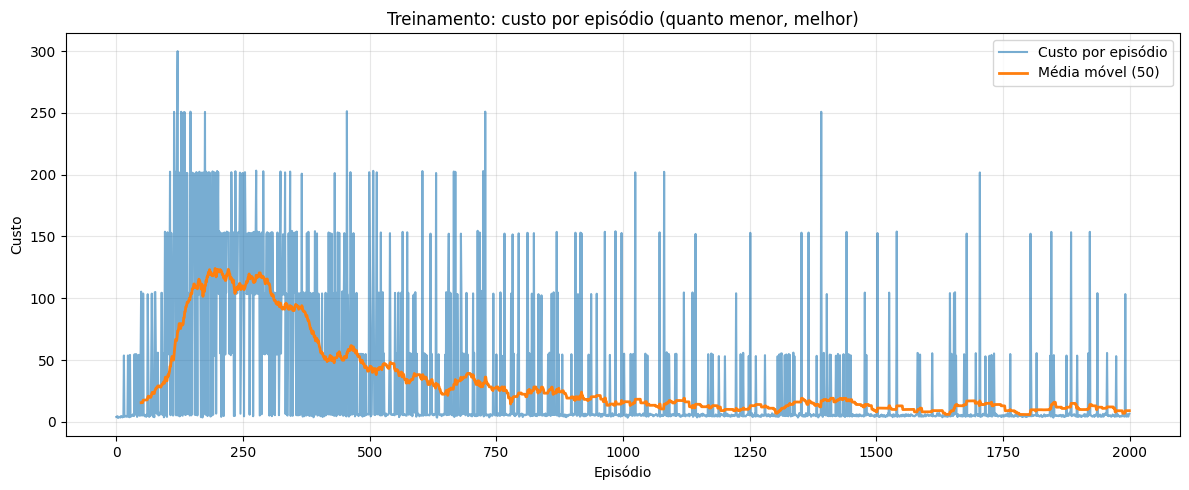

In [22]:
# ======================================================================
# Mostra o Custo por Episódio
# ======================================================================
Mostra_Custo_Episodio (custo_por_ep)


In [17]:
# ======================================================================
# FIM DO PROGRAMA
# ======================================================================